# Script to view the changes in species concentration and radiative forcing from rocket launches and object re-entries.

In [1]:

# Import modules
import sys, os
#sys.path.append('/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir')
import numpy as np
import netCDF4
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as colors
import cartopy.crs as ccrs
from gamap_colormap import WhGrYlRd
from ipywidgets import interact, IntSlider, SelectionSlider, Dropdown
import math

# Set up arrays
months =['01','02','03','04','05','06','07','08','09','10','11','12']
years = ["2020","2021","2022","2023","2024","2025","2026","2027","2028","2029"]
year_labels = [2020]
for year_count,year in enumerate(years):
    for mth in months:
        year_labels.append(int(mth)/12+year_count+2020)
filepath     = '/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir/'
rocketsims   = ['Rockets', 'SMC']
norocketsSim = 'Baseline'
Plower =200
Pupper = 1
Pmid = 5
species = ["BC","NOx","O3","Al2O3","Cly","CO","DST","H2O"]
species = ["BC","NOx","O3","Cly"]

### Retrieve concentrations from SpeciesConc over the stratosphere.

In [2]:

mon_mean_nr = np.zeros((8,len(months)*len(years),47,2))
mon_mean_wr = np.zeros((8,len(months)*len(years),47,2))
mon_mean_nr_hemispheres = np.zeros((8,len(months)*len(years),47,46,2))
mon_mean_wr_hemispheres = np.zeros((8,len(months)*len(years),47,46,2))
trop_height = []
for sim_count,sim in enumerate(rocketsims):
    count = 0
    for year_count,year in enumerate(years):
        print(year)
        for mth in months:
            print(mth)
            #if int(mth) > 2 and int(year) == 2024:
            #    continue
            #if sim_count == 1 and int(year) >= 2023:
            #    continue
            if int(year) >= 2023:
                try:
                    wr  = xr.open_dataset(filepath+sim+f"/{year}/GEOSChem.SpeciesConc.2022{mth}01_0000z.nc4") 
                    nr  = xr.open_dataset(filepath+norocketsSim+f'/{year}/GEOSChem.SpeciesConc.2022{mth}01_0000z.nc4' )
                except:
                    continue
            else:
                try:
                    if sim_count == 0:
                        wr  = xr.open_dataset(filepath+sim+f"/FDH_stratonly/GEOSChem.SpeciesConc.{year}{mth}01_0000z.nc4") 
                    else:
                        wr  = xr.open_dataset(filepath+sim+f"/GEOSChem.SpeciesConc.{year}{mth}01_0000z.nc4") 
                    nr  = xr.open_dataset(filepath+norocketsSim+f'/GEOSChem.SpeciesConc.{year}{mth}01_0000z.nc4' )
                except:
                    continue
            
            # Set up the pressure ranges.
            if sim_count == 0:
                if int(year) >= 2023:
                    met = xr.open_dataset(f'/home/ucfacb0/Scratch/StateMet/4x5/2022/GEOSChem.StateMet.2022{mth}01_0000z.nc4')
                else:
                    met = xr.open_dataset(f'/home/ucfacb0/Scratch/StateMet/4x5/{year}/GEOSChem.StateMet.{year}{mth}01_0000z.nc4')
                time, lon, lat = nr.variables['time'][:], nr.variables['lon'][:], nr.variables['lat'][:]
                P0, hyai, hybi = nr.variables['P0'], nr.variables['hyai'][:], nr.variables['hybi'][:]
                hyam, hybm = nr.variables['hyam'][:], nr.variables['hybm'][:]
                Pedge = [ hyai[i] + (hybi[i]*P0.values) for i in np.arange(len(hyai)) ]
                Pmiddle = [ hyam[i] + (hybm[i]*P0.values) for i in np.arange(len(hyam)) ]
                iu = np.argmin(np.abs([ Pedge[i] - Pupper for i in np.arange(len(Pedge)) ] )) # grid index of upper pressure level
                im = np.argmin(np.abs([ Pedge[i] - Pmid for i in np.arange(len(Pedge)) ] )) # grid index of upper pressure level
                il = np.argmin(np.abs([ Pedge[i] - Plower for i in np.arange(len(Pedge)) ] )) # grid index of lower pressure level
                
                trop_height.append(met.variables['Met_TropP'][0,:,:].mean(["lat","lon"]).item()) # tropopause height grid level
                if count == 0: 
                    trop_height.append(met.variables['Met_TropP'][0,:,:].mean(["lat","lon"]).item()) # tropopause height grid level
                met.close()
                #Pedge = Pedge[il:iu]
            
            for spec_count, spec in enumerate(species):    
                if spec == "BC":    
                    # Black carbon
                    mon_mean_nr[spec_count,count,:,sim_count] = (nr["SpeciesConcVV_BCPO"].isel(time=0).mean(["lat","lon"]).values + 
                                                        nr["SpeciesConcVV_BCPI"].isel(time=0).mean(["lat","lon"]).values) * 1e12
                    mon_mean_wr[spec_count,count,:,sim_count] = (wr["SpeciesConcVV_BCPO"].isel(time=0).mean(["lat","lon"]).values + 
                                                        wr["SpeciesConcVV_BCPI"].isel(time=0).mean(["lat","lon"]).values) * 1e12   
                
                    mon_mean_nr_hemispheres[spec_count,count,:,:,sim_count] = (nr["SpeciesConcVV_BCPO"].isel(time=0).mean(["lon"]).values + 
                                                                    nr["SpeciesConcVV_BCPI"].isel(time=0).mean(["lon"]).values) * 1e12
                    mon_mean_wr_hemispheres[spec_count,count,:,:,sim_count] = (wr["SpeciesConcVV_BCPO"].isel(time=0).mean(["lon"]).values + 
                                                                    wr["SpeciesConcVV_BCPI"].isel(time=0).mean(["lon"]).values) * 1e12       
                
                elif spec == "NOx": 
                    # NOx
                    mon_mean_nr[spec_count,count,:,sim_count] = (nr["SpeciesConcVV_NO"].isel(time=0).mean(["lat","lon"]).values + 
                                            nr["SpeciesConcVV_NO2"].isel(time=0).mean(["lat","lon"]).values) * 1e12
                    mon_mean_wr[spec_count,count,:,sim_count] = (wr["SpeciesConcVV_NO"].isel(time=0).mean(["lat","lon"]).values + 
                                            wr["SpeciesConcVV_NO2"].isel(time=0).mean(["lat","lon"]).values) * 1e12  
                
                elif spec ==  "O3":     
                # Ozone
                    mon_mean_nr[spec_count,count,:,sim_count] =  nr["SpeciesConcVV_O3"].isel(time=0).mean(["lat","lon"]).values * 1e12
                    mon_mean_wr[spec_count,count,:,sim_count] =  wr["SpeciesConcVV_O3"].isel(time=0).mean(["lat","lon"]).values * 1e12 
                    
                    mon_mean_nr_hemispheres[spec_count,count,:,:,sim_count] = nr["SpeciesConcVV_O3"].isel(time=0).mean(["lon"]).values * 1e12 
                    mon_mean_wr_hemispheres[spec_count,count,:,:,sim_count] = wr["SpeciesConcVV_O3"].isel(time=0).mean(["lon"]).values * 1e12       
                    
                elif spec ==  "Al2O3":
                    # Alumina
                    mon_mean_wr[spec_count,count,:,sim_count] =  wr["SpeciesConcVV_AL2O3"].isel(time=0).mean(["lat","lon"]).values * 1e12 
                
                elif spec ==  "Cly":
                    # Chlorine
                    mon_mean_nr[spec_count,count,:,sim_count] = (nr["SpeciesConcVV_Cl"].isel(time=0   ).mean(["lat","lon"]).values + 
                                            nr["SpeciesConcVV_Cl2"].isel(time=0  ).mean(["lat","lon"]).values * 2 +
                                            nr["SpeciesConcVV_ClNO3"].isel(time=0).mean(["lat","lon"]).values +
                                            nr["SpeciesConcVV_Cl2O2"].isel(time=0).mean(["lat","lon"]).values * 2 +
                                            nr["SpeciesConcVV_ClO"].isel(time=0  ).mean(["lat","lon"]).values +
                                            nr["SpeciesConcVV_ClNO2"].isel(time=0).mean(["lat","lon"]).values +
                                            nr["SpeciesConcVV_ClOO"].isel(time=0 ).mean(["lat","lon"]).values +
                                            nr["SpeciesConcVV_HCl"].isel(time=0  ).mean(["lat","lon"]).values +
                                            nr["SpeciesConcVV_OClO"].isel(time=0 ).mean(["lat","lon"]).values +
                                            nr["SpeciesConcVV_BrCl"].isel(time=0 ).mean(["lat","lon"]).values +
                                            nr["SpeciesConcVV_HOCl"].isel(time=0 ).mean(["lat","lon"]).values +
                                            nr["SpeciesConcVV_ICl"].isel(time=0  ).mean(["lat","lon"]).values) * 1e12
                    
                    mon_mean_wr[spec_count,count,:,sim_count] = (wr["SpeciesConcVV_Cl"].isel(time=0).mean(["lat","lon"]).values + 
                                            wr["SpeciesConcVV_Cl2"].isel(time=0  ).mean(["lat","lon"]).values * 2 +
                                            wr["SpeciesConcVV_ClNO3"].isel(time=0).mean(["lat","lon"]).values +
                                            wr["SpeciesConcVV_Cl2O2"].isel(time=0).mean(["lat","lon"]).values * 2 +
                                            wr["SpeciesConcVV_ClO"].isel(time=0  ).mean(["lat","lon"]).values +
                                            wr["SpeciesConcVV_ClNO2"].isel(time=0).mean(["lat","lon"]).values +
                                            wr["SpeciesConcVV_ClOO"].isel(time=0 ).mean(["lat","lon"]).values +
                                            wr["SpeciesConcVV_HCl"].isel(time=0  ).mean(["lat","lon"]).values +
                                            wr["SpeciesConcVV_OClO"].isel(time=0 ).mean(["lat","lon"]).values +
                                            wr["SpeciesConcVV_BrCl"].isel(time=0 ).mean(["lat","lon"]).values +
                                            wr["SpeciesConcVV_HOCl"].isel(time=0 ).mean(["lat","lon"]).values +
                                            wr["SpeciesConcVV_ICl"].isel(time=0  ).mean(["lat","lon"]).values) * 1e12
                
                elif spec ==  "CO": 
                    # Carbon Monoxide
                    mon_mean_nr[spec_count,count,:,sim_count] =  nr["SpeciesConcVV_CO"].isel(time=0).mean(["lat","lon"]).values * 1e12
                    mon_mean_wr[spec_count,count,:,sim_count] =  wr["SpeciesConcVV_CO"].isel(time=0).mean(["lat","lon"]).values * 1e12
                
                elif spec ==  "DST":
                    # Dust
                    mon_mean_nr[spec_count,count,:,sim_count] =  (nr["SpeciesConcVV_DST1"].isel(time=0).mean(["lat","lon"]).values +
                                            nr["SpeciesConcVV_DST2"].isel(time=0).mean(["lat","lon"]).values +
                                            nr["SpeciesConcVV_DST3"].isel(time=0).mean(["lat","lon"]).values +
                                            nr["SpeciesConcVV_DST4"].isel(time=0).mean(["lat","lon"]).values) * 1e12
                    mon_mean_wr[spec_count,count,:,sim_count] =  (wr["SpeciesConcVV_DST1"].isel(time=0).mean(["lat","lon"]).values +
                                            wr["SpeciesConcVV_DST2"].isel(time=0).mean(["lat","lon"]).values +
                                            wr["SpeciesConcVV_DST3"].isel(time=0).mean(["lat","lon"]).values +
                                            wr["SpeciesConcVV_DST4"].isel(time=0).mean(["lat","lon"]).values) * 1e12
                
                elif spec ==  "H2O":
                    # H2O
                    mon_mean_nr[spec_count,count,:,sim_count] =  nr["SpeciesConcVV_H2O"].isel(time=0).mean(["lat","lon"]).values * 1e12
                    mon_mean_wr[spec_count,count,:,sim_count] =  wr["SpeciesConcVV_H2O"].isel(time=0).mean(["lat","lon"]).values * 1e12
                        
            # Keep the counter going and build the x axis label array.
            count += 1
        
            wr.close()
            nr.close()
            
print(year_labels)
#trop_height.append(trop_height[-1])

2020
01
02
03
04
05
06
07
08
09
10
11
12
2021
01
02
03
04
05
06
07
08
09
10
11
12
2022
01
02
03
04
05
06
07
08
09
10
11
12
2023
01
02
03
04
05
06
07
08
09
10
11
12
2024
01
02
03
04
05
06
07
08
09
10
11
12
2025
01
02
03
04
05
06
07
08
09
10
11
12
2026
01
02
03
04
05
06
07
08
09
10
11
12
2027
01
02
03
04
05
06
07
08
09
10
11
12
2028
01
02
03
04
05
06
07
08
09
10
11
12
2029
01
02
03
04
05
06
07
08
09
10
11
12
2020
01
02
03
04
05
06
07
08
09
10
11
12
2021
01
02
03
04
05
06
07
08
09
10
11
12
2022
01
02
03
04
05
06
07
08
09
10
11
12
2023
01
02
03
04
05
06
07
08
09
10
11
12
2024
01
02
03
04
05
06
07
08
09
10
11
12
2025
01
02
03
04
05
06
07
08
09
10
11
12
2026
01
02
03
04
05
06
07
08
09
10
11
12
2027
01
02
03
04
05
06
07
08
09
10
11
12
2028
01
02
03
04
05
06
07
08
09
10
11
12
2029
01
02
03
04
05
06
07
08
09
10
11
12
[2020, 2020.0833333333333, 2020.1666666666667, 2020.25, 2020.3333333333333, 2020.4166666666667, 2020.5, 2020.5833333333333, 2020.6666666666667, 2020.75, 2020.8333333333333, 2020.91

### Output the SpeciesConc Plots for the all sources sim

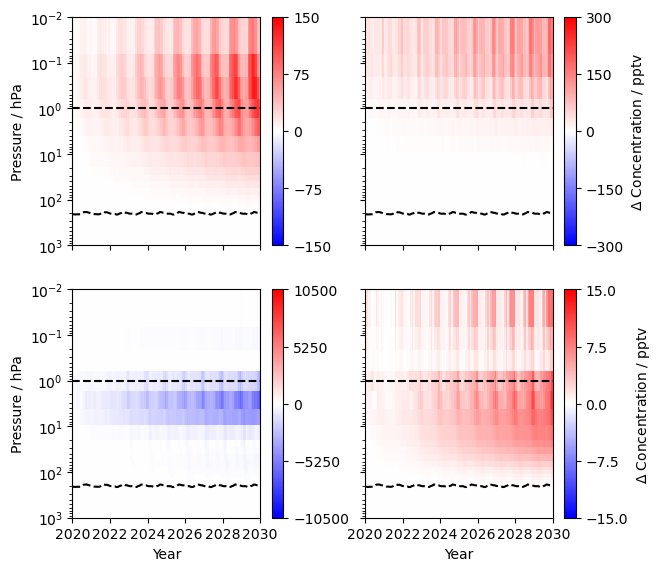

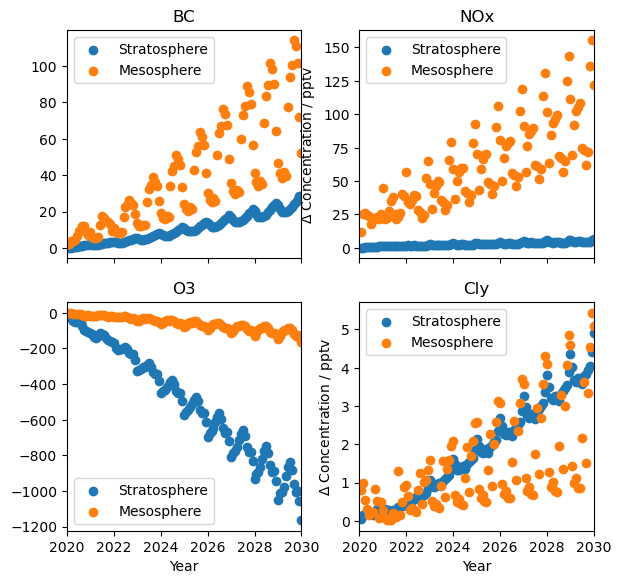

In [3]:

extent = [12000,4,0.05,0,0.2,1,2e17]
final_species = (int(np.ceil(len(species)/2))*2)
fig, ax = plt.subplots(int(np.ceil(len(species)/2)),2,figsize=(6,len(species)*1.4))
fig1, ax1 = plt.subplots(int(np.ceil(len(species)/2)),2,figsize=(6,len(species)*1.4))
rows = [0,0,1,1,2,2,3,3]
cols = [0,1,0,1,0,1,0,1]
fig.tight_layout()
fig1.tight_layout()
for spec_count in range(len(species)):
    #if spec_count == 3:
        #continue
    mon_mean = mon_mean_wr[spec_count,:,:,0]-mon_mean_nr[spec_count,:,:,0]
    
    mon_mean_plot = mon_mean
    lbl = "$\Delta$ Concentration / pptv"
    #mon_mean_plot = mon_mean / mon_mean_nr[spec_count,:,:,0] * 100
    #lbl = "$\Delta$ Conc / %"
    
    order = 10**math.floor(math.log(np.nanmax(np.abs(mon_mean_plot)), 10))
    extent = ((np.nanmax(np.abs(mon_mean_plot)) / order)).round(0)*1.5 * order
    max_ind = np.unravel_index(np.nanargmax(np.abs(mon_mean_plot)),np.shape(mon_mean_plot))
    
    plot_row = rows[spec_count]
    plot_col = cols[spec_count]
    cf = ax[plot_row,plot_col].pcolormesh(year_labels,Pedge,mon_mean_plot.T, cmap ='bwr', vmin=-extent, vmax=extent,shading='flat')
    ax[plot_row,plot_col].plot(year_labels,np.full((len(year_labels)),1),'--',color="black")
    ax[plot_row,plot_col].plot(year_labels[:len(trop_height)],trop_height,'--',color="black")
    ax[plot_row,plot_col].set_xticks(np.linspace(2020,2030,6))
    ax[plot_row,plot_col].set_xlim(2020,2030)
    ax[plot_row,plot_col].set_yscale('log')
    ax[plot_row,plot_col].set_ylim(0.01,1000)
    ax[plot_row,plot_col].invert_yaxis()
    ax[plot_row,plot_col].set_xlabel("Year")
    if spec_count not in [final_species-1,final_species-2]:
        ax[plot_row,plot_col].set_xlabel("")  
        ax[plot_row,plot_col].set_xticklabels("")
    if spec_count not in [1,3]:
        ax[plot_row,plot_col].set_ylabel("Pressure / hPa")
        lbl=""
    else:
        ax[plot_row,plot_col].set_ylabel("")  
        ax[plot_row,plot_col].set_yticklabels("")
        
    #ax[plot_row,plot_col].set_title(f"{species[spec_count]} - Max in Month {max_ind[0]+1} in Layer {max_ind[1]+1}")
    ticks=[-extent, -extent/2, 0, extent/2, extent]

    cbar = fig.colorbar(cf, ax=ax[plot_row,plot_col], orientation='vertical',ticks=ticks,label=lbl)
    #cbar.ax[plot_row,plot_col].set_yticklabels(ticks);

    ax1[plot_row,plot_col].scatter(year_labels[1:],np.mean(mon_mean_plot[:,il:iu],axis=1),label="Stratosphere")
    ax1[plot_row,plot_col].scatter(year_labels[1:],np.mean(mon_mean_plot[:,iu:],axis=1),label="Mesosphere")
    ax1[plot_row,plot_col].set_xticks(np.linspace(2020,2030,6))
    ax1[plot_row,plot_col].set_xlim(2020,2030)
    ax1[plot_row,plot_col].set_xlabel("Year")
    ax1[plot_row,plot_col].set_title(f"{species[spec_count]}")
    ax1[plot_row,plot_col].set_ylabel(lbl)
    ax1[plot_row,plot_col].legend()
    if spec_count not in [final_species-1,final_species-2]:
        ax1[plot_row,plot_col].set_xlabel("")  
        ax1[plot_row,plot_col].set_xticklabels("")

### Plot the increase in BC concentration in each hemisphere

/home/ucfacb0/miniconda3/envs/gcpy_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ucfacb0/miniconda3/envs/gcpy_env/lib/python3.9/site-packages/numpy/core/_methods.py:184: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


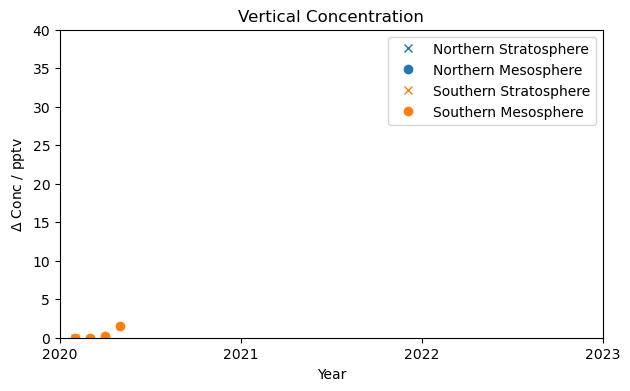

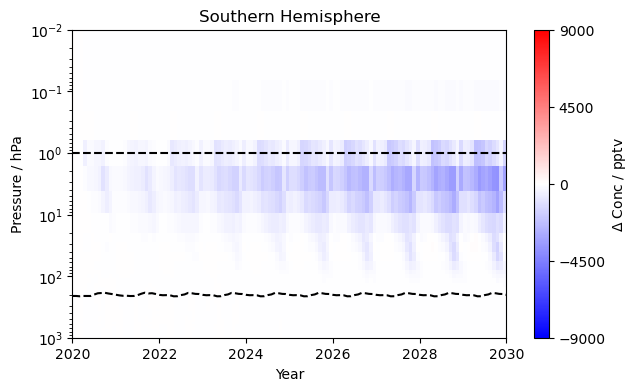

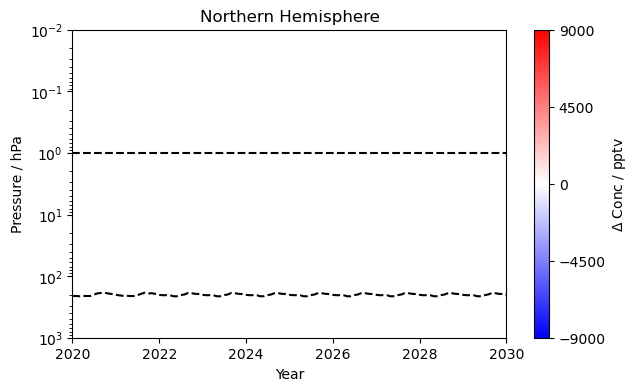

In [4]:
fig1, ax1 = plt.subplots(figsize=(7,4))
ind = np.argmin(np.abs(2-lat.values))
mon_mean = mon_mean_wr_hemispheres[:,:,:,0]-mon_mean_nr_hemispheres[:,:,:,0]
mon_mean_plot = mon_mean
lbl = "$\Delta$ Conc / pptv"

ax1.plot(year_labels[1:],np.mean(mon_mean_plot[2,:,il:iu,ind:],axis=(1,2)),"x",label="Northern Stratosphere", color='tab:blue')
ax1.plot(year_labels[1:],np.mean(mon_mean_plot[2,:,iu:,ind:],axis=(1,2))  ,"o",label="Northern Mesosphere"  , color='tab:blue')
ax1.plot(year_labels[1:],np.mean(mon_mean_plot[2,:,il:iu,:ind],axis=(1,2)),"x",label="Southern Stratosphere", color='tab:orange')
ax1.plot(year_labels[1:],np.mean(mon_mean_plot[2,:,iu:,:ind],axis=(1,2))  ,"o",label="Southern Mesosphere"  , color='tab:orange')
ax1.set_xticks(np.linspace(2020,2023,4))
ax1.set_xlim(2020,2023)
ax1.set_ylim(0,40)
ax1.set_xlabel("Year")
ax1.set_title("Concentration Per Layer")
ax1.set_ylabel(lbl)
ax1.legend()

for hemisphere in range(2):
    fig, ax = plt.subplots(figsize=(7,4))   
    order = 10**math.floor(math.log(np.nanmax(np.abs(mon_mean_plot)), 10))
    extent = ((np.nanmax(np.abs(mon_mean_plot)) / order)).round(0)*1.5 * order
    if hemisphere == 0:
        mon_mean_plot_hemi = np.mean(mon_mean_plot[2,:,:,:ind],axis=(2))
        title = "Southern Hemisphere"
    else:
        mon_mean_plot_hemi = np.mean(mon_mean_plot[2,:,:,ind:],axis=(2))
        title = "Northern Hemisphere"
    cf = ax.pcolormesh(year_labels,Pedge,mon_mean_plot_hemi.T, cmap ='bwr', vmin=-extent, vmax=extent,shading='flat')
    ax.plot(year_labels,np.full((len(year_labels)),1),'--',color="black")
    ax.plot(year_labels[:len(trop_height)],trop_height,'--',color="black")
    ax.set_xticks(np.linspace(2020,2030,6))
    ax.set_xlim(2020,2030)
    ax.set_yscale('log')
    ax.set_ylim(0.01,1000)
    ax.invert_yaxis()
    ax.set_xlabel("Year")
    ax.set_ylabel("Pressure / hPa")
    ax.set_title(title)
    ticks=[-extent, -extent/2, 0, extent/2, extent]
    ax1.set_title("Vertical Concentration")
    cbar = fig.colorbar(cf, ax=ax, orientation='vertical',
                        ticks=ticks,label=lbl)
    #cbar.ax[plot_row,plot_col].set_yticklabels(ticks);

In [5]:
import matplotlib.patches as mpatches

### Plot the stratospheric concentration change for each simulation

120 120
120 120
120 120
120 120


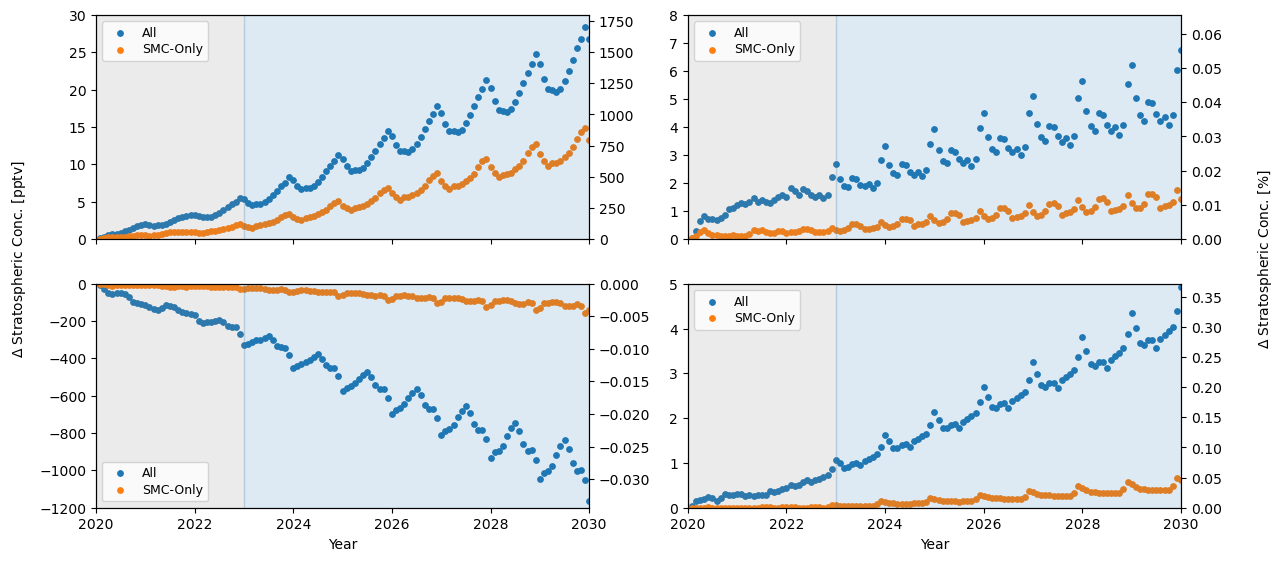

In [6]:
fig1, ax1 = plt.subplots(int(np.ceil(len(species)/2)),2,figsize=(14,len(species)*1.6))
#fig1, ax1 = plt.subplots(int(np.ceil(len(species))),1,figsize=(12,len(species)*1.4))
        
rows = [0,0,1,1,2,2,3,3]
cols = [0,1,0,1,0,1,0,1]
#rows = [0,0,1,1,2,2,3,3]
#cols = [0,1,0,1,0,1,0,1]
ylim_mins = [0,0,-1200,0]
ylim_maxs = [30,8,0,5]
#fig1.tight_layout()

for spec_count in range(len(species)):
    
    mon_mean_all_per = (mon_mean_wr[spec_count,:,:,0]-mon_mean_nr[spec_count,:,:,0]) / mon_mean_nr[spec_count,:,:,0] * 100
    mon_mean_all = (mon_mean_wr[spec_count,:,:,0]-mon_mean_nr[spec_count,:,:,0]) 
    mon_mean_smc_per = (mon_mean_wr[spec_count,:,:,1]-mon_mean_nr[spec_count,:,:,1]) / mon_mean_nr[spec_count,:,:,1] * 100
    mon_mean_smc = (mon_mean_wr[spec_count,:,:,1]-mon_mean_nr[spec_count,:,:,1])
    lbl = "$\Delta$ Stratospheric Conc. [pptv]"
    lbl_per = "$\Delta$ Stratospheric Conc. [%]"
    
    plot_row = rows[spec_count]
    plot_col = cols[spec_count]
    try:
        all_finalind = np.argwhere(np.isnan(np.mean(mon_mean_all_per[:,il:iu],axis=1)))[0][0]
    except:
        all_finalind = len(np.mean(mon_mean_all[:,il:iu],axis=1))
    try:
        smc_finalind = np.argwhere(np.isnan(np.mean(mon_mean_smc_per[:,il:iu],axis=1)))[0][0]
    except: 
        smc_finalind = len(np.mean(mon_mean_smc[:,il:iu],axis=1)) 

    print(all_finalind,smc_finalind)
    #ax1[plot_row,plot_col].scatter(year_labels[1:all_finalind+1],np.mean(mon_mean_all[:all_finalind,:il],axis=(1)),color="tab:blue",marker="d",label="All (Trop.)")
    ax1[plot_row,plot_col].scatter(year_labels[1:all_finalind+1],np.mean(mon_mean_all[:all_finalind,il:iu],axis=(1)),color="tab:blue",marker="o",s=15, facecolors='tab:blue',label="All")
    #ax1[plot_row,plot_col].scatter(year_labels[1:all_finalind+1],np.mean(mon_mean_all[:all_finalind,iu:],axis=(1)),color="tab:blue",marker="d", facecolors='none')
    #ax1[plot_row,plot_col].scatter(year_labels[1:smc_finalind+1],np.mean(mon_mean_smc[:smc_finalind,:il],axis=(1)),color="tab:orange",marker="d",label="SMC-Only (Trop.)")
    ax1[plot_row,plot_col].scatter(year_labels[1:smc_finalind+1],np.mean(mon_mean_smc[:smc_finalind,il:iu],axis=(1)),color="tab:orange",marker="o",s=15, facecolors='tab:orange',label="SMC-Only")
    #ax1[plot_row,plot_col].scatter(year_labels[1:smc_finalind+1],np.mean(mon_mean_smc[:smc_finalind,iu:],axis=(1)),color="tab:orange",marker="d", facecolors='none')
    ax2 = ax1[plot_row,plot_col].twinx()
    ax2.scatter([],[])
    
    final_norm = np.mean(mon_mean_all[all_finalind-1,il:iu])
    final_perc = np.mean(mon_mean_all_per[all_finalind-1,il:iu])
    
    ax1[plot_row,plot_col].set_xticks(np.linspace(2020,2030,6))
    ax1[plot_row,plot_col].set_xlim(2020,2030)
    ax1[plot_row,plot_col].set_xlabel("Year")
    if spec_count not in [final_species-1,final_species-2]:
        ax1[plot_row,plot_col].set_xlabel("")  
        ax1[plot_row,plot_col].set_xticklabels("")
    
    ax1[plot_row,plot_col].set_ylim(ylim_mins[spec_count],ylim_maxs[spec_count])
    ax1[plot_row,plot_col].axvspan(2020, 2023, alpha=0.15,color="tab:gray")
    ax1[plot_row,plot_col].axvspan(2023, 2030, alpha=0.15,color="tab:blue")    

    if spec_count not in [2]:
        ax1[plot_row,plot_col].legend(loc="upper left",labelspacing=0.3,fontsize=9)
        ax2.set_ylim(0,final_perc/final_norm*ylim_maxs[spec_count])
    else:
        ax1[plot_row,plot_col].legend(loc="lower left",labelspacing=0.3,fontsize=9)
        ax2.set_ylim(final_perc/final_norm*ylim_mins[spec_count],0)
    
fig1.text(0.07, 0.5, lbl, ha='center', va='center', rotation='vertical',weight="regular")    
fig1.text(0.96, 0.5, lbl_per, ha='center', va='center', rotation='vertical',weight="regular");  

(118, 42, 32)
-13591.5


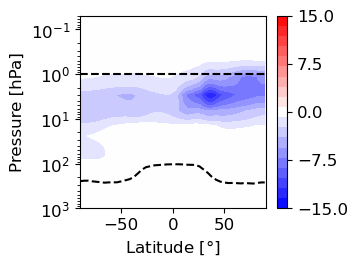

In [11]:
array_3d = mon_mean_wr_hemispheres[2,:,:,:,0]-mon_mean_nr_hemispheres[2,:,:,:,0]
flat_index = np.argmin(array_3d)
min_index = np.unravel_index(flat_index, array_3d.shape)
print(min_index)
print(array_3d[min_index])

extent = 15
lat_bounds = np.append(nr["lat_bnds"].values[:,0],90)
met = xr.open_dataset(f'/home/ucfacb0/Scratch/StateMet/4x5/2022/GEOSChem.StateMet.2022{mth}01_0000z.nc4')
trop_height = met.variables['Met_TropP'][0,:,:].mean(["lon"]).values # tropopause height grid level
met.close()
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(3,2.5))  
#cf = ax.pcolormesh(lat_bounds,Pedge,array_3d[-1,:,:]/1000, cmap ='bwr', vmin=-extent, vmax=extent,shading='flat')
cf = ax.contourf(lat.values,Pmiddle,array_3d[min_index[0],:,:]/1000, cmap ='bwr',levels=np.linspace(-15,15,20))
ax.plot(lat_bounds,np.full((len(lat_bounds)),1),'--',color="black")
ax.plot(lat.values,np.full((len(lat.values)),trop_height),'--',color="black")
ax.set_xlim(-90,90)
ax.set_yscale('log')
ax.set_ylim(0.05,1000)
ax.invert_yaxis()
ax.set_xlabel("Latitude [$\degree$]")
ax.set_ylabel("Pressure [hPa]")
ticks=[-extent, -extent/2, 0, extent/2, extent]
cbar = fig.colorbar(cf, ax=ax, orientation='vertical', ticks=ticks,label="")#"$\Delta$ Stratospheric Conc. [ppbv]");

In [8]:
from scipy.optimize import curve_fit
def f(x, A, B): # this is your 'straight line' y=f(x)
    return A*x + B

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


(120, 8)
(3, 8)
(3, 8)
(3, 8)
(3, 8)
(3, 8)
(3, 8)
(3, 8)
(3, 8)
(3, 8)
(3, 8)
-7.9276875 -9.787268518518518 -1.5962191358024693


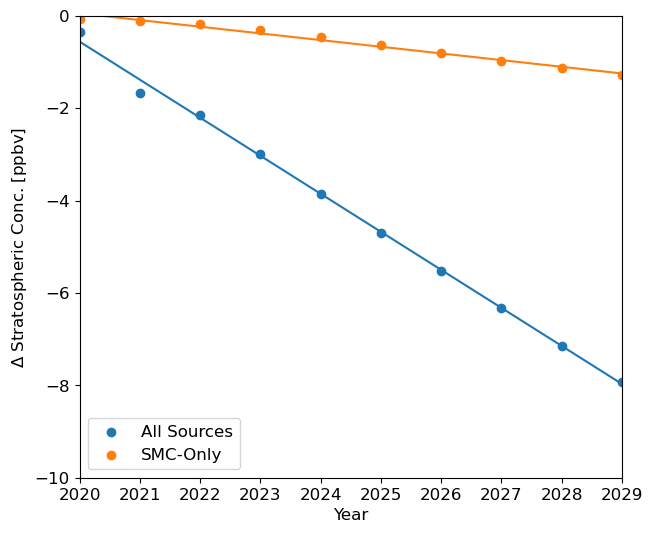

In [9]:

fig1, ax1 = plt.subplots(figsize=(7,6))
#fig1.tight_layout()

ind = np.argmin(np.abs(62-lat.values))
im = np.argmin(np.abs([ Pedge[i] - 5 for i in np.arange(len(Pedge)) ] ))

lbl = "$\Delta$ Stratospheric Conc. [ppbv]"
lbl_per = "$\Delta$ Stratospheric Conc. [%]"
annual_mean_all, annual_mean_smc = [], []
print(np.shape(mon_mean_wr_hemispheres[2,:,min_index[1],ind:,0]))
for i in range(0,120,12):
    print(np.shape(mon_mean_wr_hemispheres[2,i:i+3,min_index[1],ind:,0]))
    annual_mean_all.append(np.mean(mon_mean_wr_hemispheres[2,i:i+3,min_index[1],ind:,0]-mon_mean_nr_hemispheres[2,i:i+3,min_index[1],ind:,0])/1000)
    annual_mean_smc.append(np.mean(mon_mean_wr_hemispheres[2,i:i+3,min_index[1],ind:,1]-mon_mean_nr_hemispheres[2,i:i+3,min_index[1],ind:,1])/1000)

ax1.scatter(np.arange(2020,2030),annual_mean_all,label="All Sources")
ax1.scatter(np.arange(2020,2030),annual_mean_smc,label="SMC-Only")

popt1, pcov1 = curve_fit(f, np.arange(2020,2030), annual_mean_all) # your data x, y to fit
popt2, pcov2 = curve_fit(f, np.arange(2020,2030), annual_mean_smc) # your data x, y to fit

ax1.plot(np.arange(2020,2030),f(np.arange(2020,2030),popt1[0],popt1[1]))
ax1.plot(np.arange(2020,2030),f(np.arange(2020,2030),popt2[0],popt2[1]))
ax1.set_xticks(np.arange(2020,2030))
ax1.set_xlim(2020,2029)
ax1.set_ylim(-10,0)
ax1.set_xlabel("Year")
ax1.set_ylabel(lbl)
montreal_per = annual_mean_all[-1] / 81 *100
montreal_per_smc = annual_mean_smc[-1] / 81 *100
print(annual_mean_all[-1],montreal_per,montreal_per_smc)

ax1.legend(loc="lower left");